# Stage 8 — Compare Statewide-Coarse vs. Mole-Creek-Detailed

The core "does scale matter" question the whole two-tier design was
built to answer: for the Mole Creek area specifically, does the
statewide method (100 m, frozen, no re-tuning) agree with the
Mole-Creek-detailed method (25 m, the original prototype)?

The comparison covers the **Mole Creek karst only** (not the neighbouring karst in the 3 km buffer).

Compared on the **continuous risk score** (0-1), not classified index —
the classes are 0.2-wide bins, so two cells just either side of a class
edge would count as disagreeing, and the continuous score keeps the detail.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from karst import in_mole_creek_focus
from mapping import add_attribution, add_basemap, add_risk_colourbar, finish_map, plot_risk_continuous, raster_extent

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

mole_creek = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg")

## 8.1 Resample the statewide risk (100 m) onto the Mole Creek grid (25 m)

Nearest-neighbour, matching how the rest of this project treats resolution changes for these piecewise-constant-ish surfaces.

In [2]:
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif") as src:
    risk_mc = src.read(1)
    risk_mc_nodata = src.nodata
    mc_transform = src.transform
    mc_crs = src.crs
    mc_shape = (src.height, src.width)

with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    risk_tas_on_mc = np.full(mc_shape, risk_mc_nodata, dtype="float32")
    reproject(
        source=rasterio.band(src, 1), destination=risk_tas_on_mc,
        src_transform=src.transform, src_crs=src.crs,
        dst_transform=mc_transform, dst_crs=mc_crs,
        src_nodata=src.nodata, dst_nodata=risk_mc_nodata,
        resampling=Resampling.nearest,
    )

valid = (risk_mc != risk_mc_nodata) & (risk_tas_on_mc != risk_mc_nodata)
print(f"Valid comparison cells: {valid.sum()} / {mc_shape[0]*mc_shape[1]}")

Valid comparison cells: 412504 / 3482622


## 8.2 Agreement statistics

Statistics are reported two ways: over all valid cells, and restricted to cells where either surface is nonzero. Valid cells are now the Mole Creek karst itself, so essentially every valid cell has risk above zero and the two versions coincide. (When the comparison covered the whole 3 km buffer, the ~77% of cells that are 0 in both surfaces inflated the all-cells figure.)

In [3]:
diff_map = np.where(valid, risk_mc - risk_tas_on_mc, np.nan)
local = risk_mc[valid]
coarse = risk_tas_on_mc[valid]
diff = local - coarse

print("=== Over all valid cells (includes the ~77% that are 0 in both) ===")
print(f"r = {np.corrcoef(local, coarse)[0,1]:.3f}, exact agreement = {(diff==0).mean()*100:.1f}%, n = {len(local)}")

either_nonzero = valid & ((risk_mc > 0) | (risk_tas_on_mc > 0))
local_nz = risk_mc[either_nonzero]
coarse_nz = risk_tas_on_mc[either_nonzero]
diff_nz = local_nz - coarse_nz

print("\n=== Restricted to cells where EITHER surface is > 0 (headline) ===")
print(f"n = {len(local_nz)} ({len(local_nz)/valid.sum()*100:.1f}% of valid cells)")
print(f"r = {np.corrcoef(local_nz, coarse_nz)[0,1]:.3f}")
print(f"Mean absolute difference: {np.abs(diff_nz).mean():.4f}")
print(f"Local higher than coarse: {(diff_nz>0).mean()*100:.1f}% of cells")
print(f"Coarse higher than local: {(diff_nz<0).mean()*100:.1f}% of cells")

=== Over all valid cells (includes the ~77% that are 0 in both) ===
r = 0.929, exact agreement = 0.0%, n = 412504

=== Restricted to cells where EITHER surface is > 0 (headline) ===
n = 412504 (100.0% of valid cells)
r = 0.929
Mean absolute difference: 0.0133
Local higher than coarse: 28.1% of cells
Coarse higher than local: 71.9% of cells


**Result:** over the Mole Creek karst (412,504 cells), the local and statewide-coarse risk surfaces correlate at r = 0.929, with a mean absolute difference of 0.0133 on the 0-1 scale (both numbers from the equation now including the slope factor). The coarse surface is higher than the local one in most cells (71.9%), so the two agree on pattern more than on exact level. A likely contributor is how land cover is resampled to 100 m (majority class) against the 25 m grid, which shifts each system's mean pressure slightly; this has not been isolated.

## 8.3 Visual comparison

cell_4:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


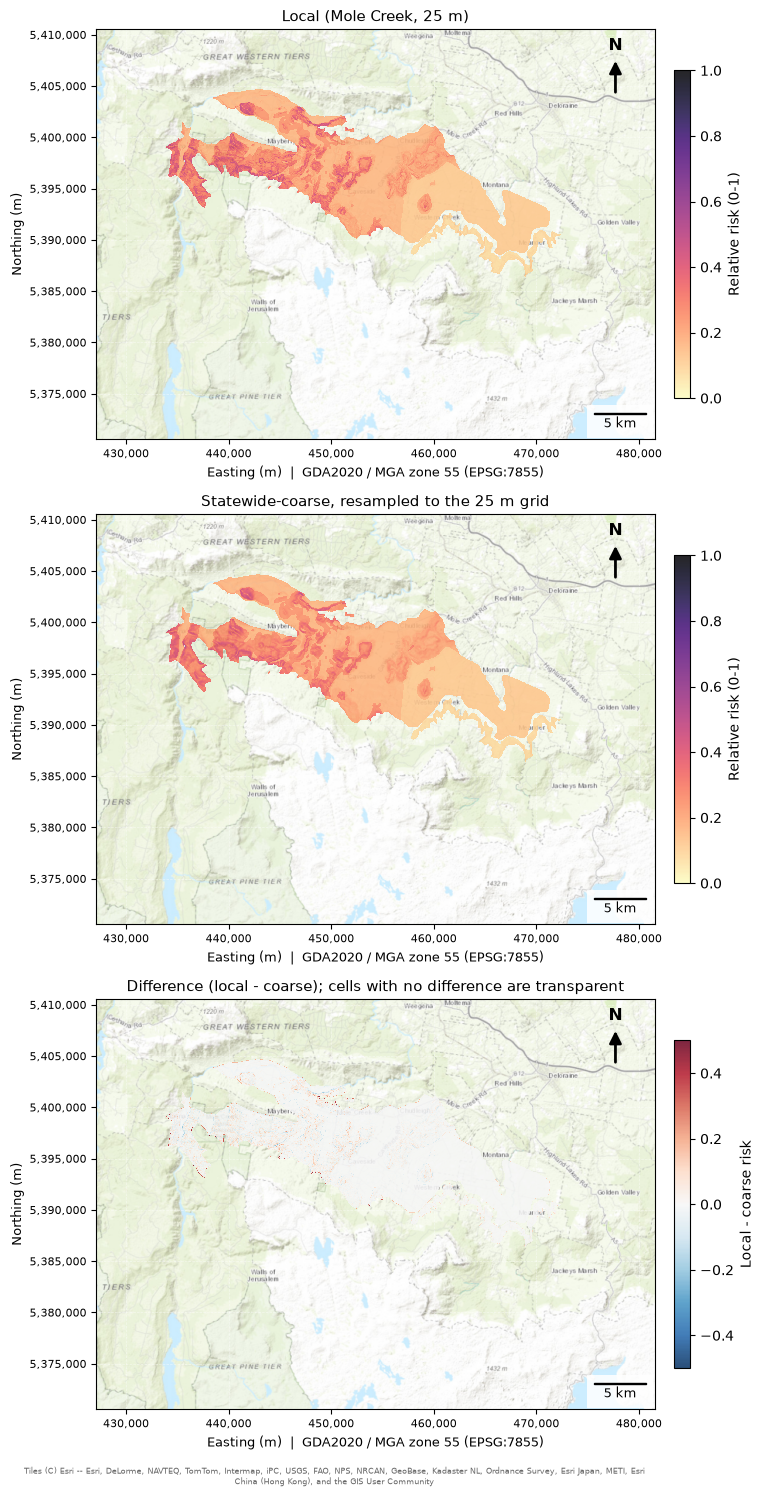

In [4]:
bounds = tuple(mole_creek.total_bounds)
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
for ax, surface, title in [
    (axes[0], np.where(valid, risk_mc, np.nan), "Local (Mole Creek, 25 m)"),
    (axes[1], np.where(valid, risk_tas_on_mc, np.nan), "Statewide-coarse, resampled to the 25 m grid"),
]:
    add_basemap(ax, bounds, margin=0, zoom=11)
    image = plot_risk_continuous(ax, surface, mc_transform)
    add_risk_colourbar(ax, image)
    ax.set_title(title, fontsize=11)
    finish_map(ax)

ax = axes[2]
add_basemap(ax, bounds, margin=0, zoom=11)
shown = np.ma.masked_where(~np.isfinite(diff_map) | np.isclose(diff_map, 0), diff_map)
im = ax.imshow(shown, cmap="RdBu_r", vmin=-0.5, vmax=0.5, alpha=0.85, interpolation="nearest",
               extent=raster_extent(mc_transform, diff_map.shape), zorder=2)
fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="Local - coarse risk")
ax.set_title("Difference (local - coarse); cells with no difference are transparent", fontsize=11)
finish_map(ax)
add_attribution(axes[-1])
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.show()

## 8.4 Per-named-area comparison

Uses **pooled** aggregation: all polygons sharing a name are masked together in one operation, matching Stage 6.

In [5]:
karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])]
karst_mc = karst_mc[(karst_mc["karst_intensity"] > 0) & in_mole_creek_focus(karst_mc)].copy()

rows = []
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif") as src_local, \
     rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src_coarse:
    for name, group in karst_mc.groupby("KNAME"):
        geoms = list(group.geometry)
        local_img, _ = mask(src_local, geoms, crop=True, nodata=risk_mc_nodata)
        local_vals = local_img[0]
        local_vals = local_vals[local_vals != risk_mc_nodata]
        coarse_img, _ = mask(src_coarse, geoms, crop=True, nodata=src_coarse.nodata)
        coarse_vals = coarse_img[0]
        coarse_vals = coarse_vals[coarse_vals != src_coarse.nodata]
        rows.append({
            "KNAME": name,
            "local_mean_risk": local_vals.mean() if len(local_vals) else np.nan,
            "coarse_mean_risk": coarse_vals.mean() if len(coarse_vals) else np.nan,
            "local_n_pixels": len(local_vals),
            "coarse_n_pixels": len(coarse_vals),
        })

comparison = pd.DataFrame(rows).sort_values("local_mean_risk", ascending=False)
comparison["difference"] = comparison["local_mean_risk"] - comparison["coarse_mean_risk"]
comparison.to_csv(outpath / "stage8_comparison_table.csv", index=False)

n_missing = comparison[["local_mean_risk", "coarse_mean_risk"]].isna().any(axis=1).sum()
print(f"Named areas with zero valid pixels in one surface (too small to survive rasterisation, excluded from ranking): {n_missing}")
print()
print(comparison.to_string(index=False))

Named areas with zero valid pixels in one surface (too small to survive rasterisation, excluded from ranking): 0

                       KNAME  local_mean_risk  coarse_mean_risk  local_n_pixels  coarse_n_pixels  difference
Mole Creek  (Chudleigh Hill)         0.267796          0.290133             214               13   -0.022337
                  Mole Creek         0.201511          0.201218          388179            24260    0.000293
     Meander - Western Creek         0.088970          0.087591           24111             1507    0.001379


## Where they agree, and where they diverge

Mole Creek (0.2015 local, 0.2012 coarse) and Meander - Western Creek (0.0890 local, 0.0876 coarse) agree to within 0.0014. **Mole Creek (Chudleigh Hill)** shows the largest gap (0.2678 local, 0.2901 coarse) but is tiny: 214 pixels at 25 m and 13 at 100 m. A gap on that few pixels is a small-sample effect, not evidence about resolution. Read each gap against its pixel counts (`local_n_pixels` / `coarse_n_pixels`).

Earlier versions of this comparison (before slope was folded into the frozen formula) showed larger gaps, such as 0.092 for Stockers Plain (a neighbouring system, now outside the Mole Creek focus). Most of that came from inconsistent aggregation and ungrouped pressure before Stages 6 and 7 were corrected, not from scale.

## Stage 8 outputs

- `stage8_comparison_table.csv` — per-named-area local vs. coarse comparison, with pixel counts

**Next (Stage 9):** sensitivity analysis — alternative weight emphases,
the optional rainfall experiment (`KAVRAIN`), and the multi-year
land-use trend now made easy by the `src/landuse.py` refactor.